In [18]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Housekeeping

In [19]:
figure_path = '../Figures/OOI_metrics'
os.makedirs(figure_path, exist_ok=True)

# Plots

In [25]:
metrics = pd.read_excel('../../GlobalMetrics.xlsx', sheet_name='plots')

In [26]:
metrics

,SampleID,Platform,TotalTranscripts,nCounts,nGenes,DV200,PMI
0,P1212,Xenium,10.3,13,9,40.02,35.00
1,P1212,MERSCOPE,5.9,8,7,40.02,35.00
2,P5011,Xenium,9.3,11,8,54.58,14.50
3,P5011,MERSCOPE,3.2,5,4,54.58,14.50
4,P7113,Xenium,15.0,19,14,43.52,19.16
5,P7113,MERSCOPE,9.3,21,14,43.52,19.16
6,P7513,Xenium,14.2,24,15,53.01,35.20
7,P7513,MERSCOPE,24.9,57,31,53.01,35.20


In [7]:
s_id = metrics['SampleID'].unique()

In [8]:
s_id

array(['P1212', 'P5011', 'P7113', 'P7513'], dtype=object)

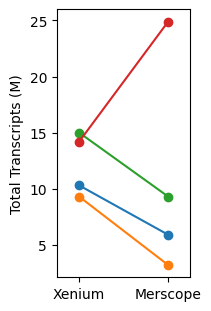

In [20]:
plt.figure(figsize=(2,3), constrained_layout=True)

for i in s_id:

    val_merscope = metrics[(metrics['SampleID'] == i) & (metrics['Platform'] == 'MERSCOPE')]['TotalTranscripts']
    val_xenium = metrics[(metrics['SampleID'] == i) & (metrics['Platform'] == 'Xenium')]['TotalTranscripts']
    
    plt.plot([0,1], [val_xenium, val_merscope], 'o-')

plt.xticks([0,1], ['Xenium', 'Merscope'])
plt.ylabel('Total Transcripts (M)')
plt.xlim(-.25, 1.25)
plt.savefig(os.path.join(figure_path, 'total_transcripts.png'), dpi=300)
plt.show()

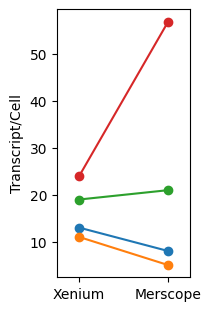

In [23]:
plt.figure(figsize=(2,3), constrained_layout=True)

for i in s_id:

    val_merscope = metrics[(metrics['SampleID'] == i) & (metrics['Platform'] == 'MERSCOPE')]['nCounts']
    val_xenium = metrics[(metrics['SampleID'] == i) & (metrics['Platform'] == 'Xenium')]['nCounts']
    
    plt.plot([0,1], [val_xenium, val_merscope], 'o-')

plt.xticks([0,1], ['Xenium', 'Merscope'])
plt.ylabel('Transcript/Cell')
plt.xlim(-.25, 1.25)
plt.savefig(os.path.join(figure_path, 'transcripts_cell.png'), dpi=300)
plt.show()

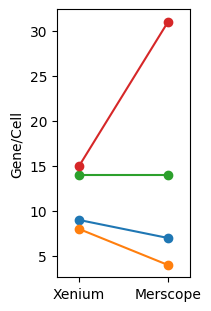

In [24]:
plt.figure(figsize=(2,3), constrained_layout=True)

for i in s_id:

    val_merscope = metrics[(metrics['SampleID'] == i) & (metrics['Platform'] == 'MERSCOPE')]['nGenes']
    val_xenium = metrics[(metrics['SampleID'] == i) & (metrics['Platform'] == 'Xenium')]['nGenes']
    
    plt.plot([0,1], [val_xenium, val_merscope], 'o-')

plt.xticks([0,1], ['Xenium', 'Merscope'])
plt.ylabel('Gene/Cell')
plt.xlim(-.25, 1.25)
plt.savefig(os.path.join(figure_path, 'gene_cell.png'), dpi=300)
plt.show()

<Axes: xlabel='DV200', ylabel='nGenes'>

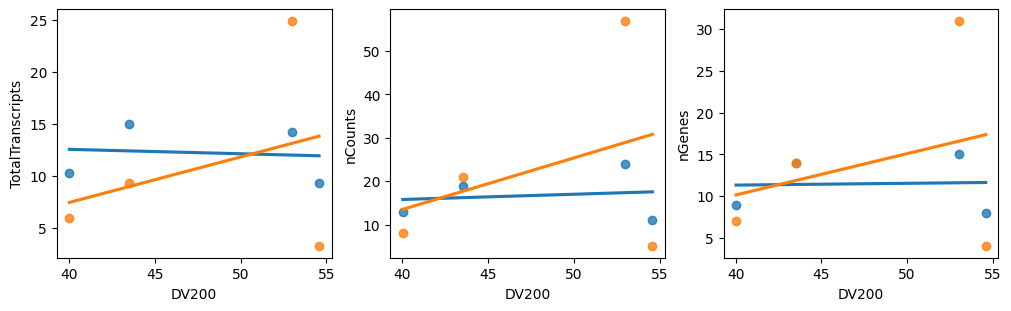

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,3), constrained_layout=True)

sns.regplot(data=metrics[metrics['Platform'] == 'Xenium'], x='DV200', y='TotalTranscripts',ci=0, ax=ax[0])
sns.regplot(data=metrics[metrics['Platform'] == 'MERSCOPE'], x='DV200', y='TotalTranscripts',ci=0, ax=ax[0])

sns.regplot(data=metrics[metrics['Platform'] == 'Xenium'], x='DV200', y='nCounts',ci=0, ax=ax[1])
sns.regplot(data=metrics[metrics['Platform'] == 'MERSCOPE'], x='DV200', y='nCounts',ci=0, ax=ax[1])

sns.regplot(data=metrics[metrics['Platform'] == 'Xenium'], x='DV200', y='nGenes',ci=0, ax=ax[2])
sns.regplot(data=metrics[metrics['Platform'] == 'MERSCOPE'], x='DV200', y='nGenes',ci=0, ax=ax[2])

<Axes: xlabel='PMI', ylabel='TotalTranscripts'>

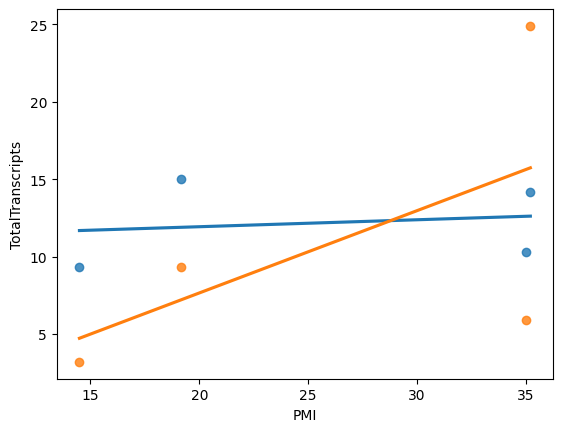

In [36]:
sns.regplot(data=metrics[metrics['Platform'] == 'Xenium'], x='PMI', y='TotalTranscripts',ci=0)
sns.regplot(data=metrics[metrics['Platform'] == 'MERSCOPE'], x='PMI', y='TotalTranscripts',ci=0)